# PV String Heatmap — v1.5 (Fase 2 + Wave 11)

Notebook v1.5 = main repo v1.4 (20260514) + Wave 7 PR analysis + Wave 9 preprocessing
flag readout + Wave 11 curtailment cross-check.

**Pipeline modules:**

Phase 0 (refactor):
- `pv_pipeline.data_loader`   — gdown download + Excel ingestion
- `pv_pipeline.transformations` — ManageObject→Inverter_ID, PV power, pivot
- `pv_pipeline.string_config` — load `config/strings.yaml` (EMPTY_PV_MAP)
- `pv_pipeline.viz`           — heatmap per-inverter

Phase 1 (M2e Hybrid Availability): `pv_pipeline.{core, m2_config, availability}`

Sprint 3.1 + 3.2 (POA + Panel + Albedo + Tcell):
- `pv_pipeline.poa` — POAProvider (Perez transposition, multi-year)
- `pv_pipeline.panel_spec` — Jinko JKM625N PanelSpec
- `pv_pipeline.cell_temp` — CellTempProvider + SAPM fallback (Wave 6)

Sprint 4.A (POA-aware M2b detectors):
- `pv_pipeline.peer_zscore`  — R-string Z-score with voc_ratio
- `pv_pipeline.open_circuit` — I_string / I_q95 ratio
- `pv_pipeline.ground_fault` — V-to-ground triple-signal

Sprint 3.3 (Baseline accumulator): `pv_pipeline.baseline`

Fase 2 (Physics + multi-source + Hampel):
- `pv_pipeline.physics` — Pmax / Kt / DeltaP / PR / active_power_integration
- `pv_pipeline.preprocessing` — Hampel outlier filter (Wave 3 + 9 A/B)
- `pv_pipeline.weather` — Ambient / WindSpeed / WindDirection loaders (Wave 5, 4-WS)
- `pv_pipeline.generation` — GenerationLoader (Wave 7) + Wave 11 Curtailment/Deem Dispatch

**Cell map:**
1. Config + download Google Drive folder
2. Load Excel + transform
3. Heatmap per inverter
4. M2 Pipeline UNIFIED (M2e + 3 M2b detectors) + Wave 9 preprocessing flag readout
5. **NEW** Performance Ratio + Curtailment cross-check (Wave 7 + Wave 11)
6. Sprint 3.1 + 3.2 Sanity (POA + Panel + Albedo + Tcell)
7. Sprint 3.3 Baseline Accumulator (manual daily save)
8. Save df_plot to CSV (Phase 0 legacy)

**Wave 11 highlight (curtailment cross-check):**
Untuk setiap hari dengan PR < 0.65, sistem cek kolom R (Curtailment) di
`IKN Generation.xlsx`. Jika `Yes` → low PR explained by operational curtailment
(busbar setpoint reached). Jika `No` → unexplained → potential fault, investigate.
Kolom Q (Deem Dispatch kWh) = loss kWh harian disepakati setiap bulan akibat curtailment.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

REPO_DIR = "/content/drive/MyDrive/Cek PV String"

required = [
    "pv_pipeline/__init__.py",
    "pv_pipeline/data_loader.py",
    "pv_pipeline/weather/__init__.py",
    "pv_pipeline/weather/loader.py",
    "pv_pipeline/poa/__init__.py",
    "pv_pipeline/generation/__init__.py",
    "pv_pipeline/m2a/__init__.py",
    "config/strings.yaml",
]

missing = [p for p in required if not os.path.exists(os.path.join(REPO_DIR, p))]
print("Missing files:", missing)
assert not missing, "Repo di Drive belum lengkap."

# Sesuaikan path ini dengan lokasi folder Anda di Drive:
REPO_DIR = '/content/drive/MyDrive/Cek PV String'

import os, sys
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
print('CWD:', os.getcwd())
print('pv_pipeline visible:', os.path.exists(os.path.join(REPO_DIR, 'pv_pipeline')))

Mounted at /content/drive
Missing files: []
CWD: /content/drive/MyDrive/Cek PV String
pv_pipeline visible: True


In [2]:
# Cell 1 — Config + download Google Drive folder
from pathlib import Path
import os, sys
from datetime import time as dtime

def find_repo_root(start=None):
    p = Path(start or os.getcwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "pv_pipeline").is_dir() and (candidate / "config").is_dir():
            return candidate
    raise RuntimeError("Repo root tidak ditemukan dari cwd/notebook location.")

REPO_DIR = str(find_repo_root())
os.chdir(REPO_DIR)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

from pv_pipeline.data_loader import download_from_gdrive, find_expected_files

# ===== USER CONFIG (edit per-run) =====
DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/17JX8ZaH0Gh24e_8DUKqKS9Rhpzvjx0IL"
EXPECTED_FILES   = ['1-2.xlsx', '3-10.xlsx']

EXCEL_HEADER_ROW = 3
USECOLS          = None
NROWS            = None

# Selection rules (kompat v1.2)
N_WB01_WB02_TOTAL = 10
N_WB_REST         = 29
SNAPSHOT_TIME     = dtime(18, 0)
TOLERANCE_MINUTES = 15

# Visual & string config
CELL_SIZE       = 0.22
PV_MAX_ALLOWED  = 28
STRINGS_YAML    = os.path.join(REPO_DIR, 'config', 'strings.yaml')
# =====================================

FOLDER     = download_from_gdrive(DRIVE_FOLDER_URL, EXPECTED_FILES)
FILE_PATHS = find_expected_files(FOLDER, EXPECTED_FILES)

_missing = [f for f in EXPECTED_FILES
            if not any(os.path.basename(p).lower() == f.lower() for p in FILE_PATHS)]
if _missing:
    print("Warning: expected files not found:", _missing)
else:
    print("All expected files found.")

print("FOLDER     :", FOLDER)
print("FILE_PATHS :")
for p in FILE_PATHS:
    print(" -", p)

Retrieving folder contents


Processing file 1eQtOtrPE36VQ2hcoiJy4TSektT6BYtTn 1-2.xlsx
Processing file 1bvnpwCBoNAhu29x4RP6BOqf9gM6Hb0s8 3-10.xlsx
Processing file 19Oo_pdRjgBfJpbzVANPcQ2Bt9pSvG6mc Historical_Data_20260209000000_20260209235959_20260209181928.zip
Processing file 1B7oJMnMPKoEGgFKzocCRNRkckKMvc3-4 Historical_Data_20260209000000_20260209235959_2026020918191338.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1eQtOtrPE36VQ2hcoiJy4TSektT6BYtTn
To: /tmp/gdrive_b_7g8ku5/1-2.xlsx
100%|██████████| 5.40k/5.40k [00:00<00:00, 7.38MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bvnpwCBoNAhu29x4RP6BOqf9gM6Hb0s8
To: /tmp/gdrive_b_7g8ku5/3-10.xlsx
100%|██████████| 13.3M/13.3M [00:00<00:00, 81.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=19Oo_pdRjgBfJpbzVANPcQ2Bt9pSvG6mc
To: /tmp/gdrive_b_7g8ku5/Historical_Data_20260209000000_20260209235959_20260209181928.zip
100%|██████████| 12.2M/12.2M [00:00<00:00, 109MB/s]
Downloading...
From: https://drive.google.com/uc?id=1B7oJMnMPKoEGgFKzocCRNRkckKMvc3-4
To: /tmp/gdrive_b_7g8ku5/Historical_Data_20260209000000_20260209235959_2026020918191338.zip
100%|██████████| 4.60k/4.60k [00:00<00:00, 11.9MB/s]

Found '1-2.xlsx' as: /tmp/gdrive_b_7g8ku5/1-2.xlsx
Found '3-10.xlsx' as: /tmp/gdrive_b_7g8ku5/3-10.xlsx
All expected files found.
FOLDER     : /tmp/gdrive_b_7g8ku5
FILE_PATHS :
 - /tmp/gdrive_b_7g8ku5/1-2.xlsx
 - /tmp/gdrive_b_7g8ku5/3-10.xlsx



Download completed


In [3]:
# Cell 2 — Load Excel + transform (data-processing only, no plot)
from pv_pipeline.data_loader import load_and_prepare_data
from pv_pipeline.transformations import (
    add_inverter_id, add_pv_power_columns, add_total_pv_power, make_pivot,
)

combined_df = load_and_prepare_data(
    folder_path     = FOLDER,
    expected_files  = EXPECTED_FILES,
    excel_header_row= EXCEL_HEADER_ROW,
    usecols         = USECOLS,
    nrows           = NROWS,
)
print("Loaded combined_df rows:", combined_df.shape[0],
      "columns:", combined_df.shape[1])

combined_df = add_inverter_id(combined_df)
print(f"Found {combined_df['Inverter_ID'].nunique()} unique Inverter_IDs.")

combined_df, pv_cols = add_pv_power_columns(combined_df)
combined_df          = add_total_pv_power(combined_df, pv_cols)
print(f"Created {len(pv_cols)} PV power columns.")
print(f"Total_PV_power_kW non-null count: "
      f"{combined_df['Total_PV_power_kW'].notna().sum()}")

pivot = make_pivot(combined_df)
print(f"Pivot table shape: {pivot.shape}")

/content/drive/MyDrive/Cek PV String/pv_pipeline/data_loader.py:158: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(dfs, ignore_index=True, sort=False)


Loaded combined_df rows: 21439 columns: 117
Found 144 unique Inverter_IDs.
Created 36 PV power columns.
Total_PV_power_kW non-null count: 21439
Pivot table shape: (144, 221)


In [4]:
# Cell 3 — Heatmap per inverter (PV1..PV28 × Start Time)
from pv_pipeline.transformations import prepare_df_work
from pv_pipeline.string_config  import get_empty_pv_map
from pv_pipeline.viz            import plot_all_inverters

EMPTY_PV_MAP_CLEAN = get_empty_pv_map(STRINGS_YAML, pv_max_allowed=PV_MAX_ALLOWED)
print(f"Loaded EMPTY_PV_MAP: {len(EMPTY_PV_MAP_CLEAN)} inverter entries")

df_work, df_plot, pv_keep = prepare_df_work(combined_df, pv_max_allowed=PV_MAX_ALLOWED)
print(f"df_work rows={len(df_work)}, df_plot rows={len(df_plot)}, "
      f"pv_keep cols={len(pv_keep)}")

MAX_TO_PLOT = None  # None => plot all inverters
count, errors = plot_all_inverters(
    df_plot         = df_plot,
    cell_size       = CELL_SIZE,
    empty_pv_map    = EMPTY_PV_MAP_CLEAN,
    pv_max_allowed  = PV_MAX_ALLOWED,
    max_to_plot     = MAX_TO_PLOT,
    pause_seconds   = 0.15,
    close_after_show= False,
)

Output hidden; open in https://colab.research.google.com to view.

In [5]:
# Cell 4 - M2 Pipeline UNIFIED (M2e Availability + POA-aware M2b)
# -----------------------------------------------------------------
# Gabungkan M2eAvailability + POA-aware M2b/M2a detectors dalam satu
# pipeline cell. Semua modul di-import langsung dari main repo package
# pv_pipeline.
#
# Auto-detect tanggal dari combined_df['Start Time'].
# Output: outputs/m2_findings_{datestr}.{jsonl,xlsx} (multi-sheet).

import os
import warnings
from collections import Counter
import pandas as pd

from pv_pipeline.availability import M2eAvailability
from pv_pipeline.cell_temp import CellTempProvider
from pv_pipeline.core import M2Engine
from pv_pipeline.ground_fault import M2bGroundFault
from pv_pipeline.iforest import M2IForest
from pv_pipeline.m2_config import load_m2_config
from pv_pipeline.m2a.low_irradiance import M2aLowIrradiance
from pv_pipeline.m2a.shading import M2aShading
from pv_pipeline.m2a.soiling import M2aSoiling
from pv_pipeline.mppt_ratio import M2bMpptRatio
from pv_pipeline.open_circuit import M2bOpenCircuit
from pv_pipeline.panel_spec import PanelSpec
from pv_pipeline.peer_zscore import M2bPeerZScore
from pv_pipeline.poa import POAProvider

warnings.simplefilter("ignore", UserWarning)
#warnings.simplefilter("default", UserWarning)

print("[m2-pipeline] modules loaded from pv_pipeline:")
print("  M2eAvailability  : Phase 1, M2e Hybrid Availability")
print("  M2bPeerZScore    : POA-gated R-string z-score")
print("  M2bOpenCircuit   : POA-gated I/I_q95 < 5%")
print("  M2bGroundFault   : V-to-ground triple-signal")
print("  M2bMpptRatio     : I_string vs median partner se-MPPT (mppt_map, ratio-gated, 2026-06-12)")
print("  M2IForest        : IsolationForest unsupervised per-inverter (Fase 3 Task #2, opt-in)")
print("  M2aShading       : Diurnal CV + PR-proxy whole-inverter shading (Fase 3 Task #4, opt-in)")
print("  M2aLowIrradiance : PR-proxy slope di low-band (50-250 W/m^2) underperform (Fase 3 Task #6, opt-in)")
print("  M2aSoiling       : rdtools SRR site-level soiling detector (Fase 3 Task #5 SKELETON, opt-in, gracefully insufficient_data sampai >=90 days baseline)")

REPO_DIR = globals().get("REPO_DIR", os.getcwd())

# --- Resolve config paths ---------------------------------------------------
def _resolve(cfg_filename: str) -> str:
    for base in [os.path.join(REPO_DIR, "config"), "config"]:
        p = os.path.join(base, cfg_filename)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"[m2-pipeline] {cfg_filename!r} not found.")


M2_CFG_PATH = _resolve("m2_config.yaml")
GEOM_PATH = _resolve("site_geometry.yaml")
PANEL_PATH = _resolve("panel_spec.yaml")
print(f"\n[m2-pipeline] m2_config: {M2_CFG_PATH}")

cfg = load_m2_config(M2_CFG_PATH)


# --- Pre-check combined_df --------------------------------------------------
if "combined_df" not in globals():
    raise RuntimeError("[m2-pipeline] combined_df missing. Run Cell 1 + Cell 2 dulu.")

required = ["Inverter_ID", "Start Time", "Inverter status"]
missing = [c for c in required if c not in combined_df.columns]
if missing:
    raise RuntimeError(f"[m2-pipeline] missing columns: {missing}")


# --- Auto-detect tanggal ----------------------------------------------------
st = pd.to_datetime(combined_df["Start Time"], errors="coerce").dropna()
st_dates = sorted(st.dt.date.unique())
if len(st_dates) == 1:
    DATA_DATESTR = st_dates[0].strftime("%Y%m%d")
else:
    DATA_DATESTR = f"{st_dates[0].strftime('%Y%m%d')}-{st_dates[-1].strftime('%Y%m%d')}"
print(f"\n[m2-pipeline] data dates = {DATA_DATESTR}  ({len(st_dates)} day(s))")
print(f"[m2-pipeline] combined_df shape = {combined_df.shape}")


# --- Build shared infrastructure (POA + Panel + Tcell) ----------------------
print(f"\n[m2-pipeline] building shared infrastructure...")
poa_provider = POAProvider.from_yaml(GEOM_PATH)
panel_spec = PanelSpec.from_yaml(PANEL_PATH)
cell_temp_provider = CellTempProvider.from_geometry_yaml(GEOM_PATH)
print(f"  POAProvider: pyranometer={bool(poa_provider.pyranometer)} "
      f"pvlib={bool(poa_provider.pvlib)} albedo_loader={bool(poa_provider.albedo_loader)}")


# --- Build M2 engine: M2e + 3 POA-aware M2b ---------------------------------
sm_e = M2eAvailability()
sm_peer = M2bPeerZScore(poa=poa_provider, panel=panel_spec, cell_temp=cell_temp_provider)
sm_oc = M2bOpenCircuit(poa=poa_provider)
sm_gf = M2bGroundFault(poa=poa_provider, panel=panel_spec, cell_temp=cell_temp_provider)
sm_mppt = M2bMpptRatio(poa=poa_provider)
sm_iforest = M2IForest(poa=poa_provider)
sm_shading = M2aShading(poa=poa_provider)
sm_low_irr = M2aLowIrradiance(poa=poa_provider)
sm_soiling = M2aSoiling(poa=poa_provider)
submodules = [sm_e, sm_peer, sm_oc, sm_gf, sm_mppt, sm_iforest, sm_shading, sm_low_irr, sm_soiling]

# V_to_ground availability check
v_gnd_candidates = ["Voltage between PV– and the ground(V)", "Voltage between PV- and the ground(V)"]
has_v_gnd = any(c in combined_df.columns for c in v_gnd_candidates)
print(f"\n[m2-pipeline] V_to_ground available: {has_v_gnd}")
print(f"[m2-pipeline] running {len(submodules)} submodules...")
print(f"  (M2b detectors akan loop di {len(cfg['poa']['sources_to_emit'])} POA sources)")

engine = M2Engine(submodules)
findings = engine.run_all(combined_df, cfg)

# --- Per-detector exclude_from_findings_sheet filter (2026-05-23) -----------
# Findings dari detector dengan exclude_from_findings_sheet=True dibuang dari
# Findings sheet utama + Cell 7 auto-skip. Artifact sheets per-detector TETAP
# di-emit di xlsx (sm.artifacts tidak dipengaruhi).
EXCLUDE_CFG_MAP = {
    "M2_iforest":         "m2_iforest",
    "M2a_shading":        "m2a_shading",
    "M2a_low_irradiance": "m2a_low_irradiance",
    "M2a_soiling":        "m2a_soiling",
    "M2b_mppt_ratio":     "m2b_mppt_ratio",
}
findings_all = list(findings)  # preserve full list untuk diagnostic
excluded_counts = {}
for _sm_name, _cfg_key in EXCLUDE_CFG_MAP.items():
    _det_cfg = cfg.get(_cfg_key, {}) or {}
    if not _det_cfg.get("exclude_from_findings_sheet", False):
        continue
    _n_before = sum(1 for _f in findings if _f.sub_module == _sm_name)
    if _n_before == 0:
        continue
    findings = [_f for _f in findings if _f.sub_module != _sm_name]
    excluded_counts[_sm_name] = _n_before
if excluded_counts:
    print(f"\n[m2-pipeline] excluded from Findings sheet + Cell 7 auto-skip:")
    for _sm, _n in sorted(excluded_counts.items()):
        print(f"  {_sm:25s} : {_n:5d} findings hidden (artifacts tetap di per-detector sheets)")
print(f"[m2-pipeline] findings: total={len(findings_all)} -> shown_in_Findings_sheet={len(findings)}")
# --- end exclude filter ----------------------------------------------------


# --- Bridge M2eAvailability legacy artifacts ke self.artifacts --------------
if getattr(sm_e, "last_all_strings_df", None) is not None and not sm_e.last_all_strings_df.empty:
    sm_e.artifacts["AllStrings"] = sm_e.last_all_strings_df
if getattr(sm_e, "last_inverter_log_df", None) is not None and not sm_e.last_inverter_log_df.empty:
    sm_e.artifacts["InverterLog"] = sm_e.last_inverter_log_df


# --- Wave 11 hotfix #3: artifact summary per submodule -----------------------
print(f"\n[m2-pipeline] artifact summary (per submodule):")
for sm_inst in submodules:
    sm_name = getattr(sm_inst, "name", sm_inst.__class__.__name__)
    arts = getattr(sm_inst, "artifacts", {}) or {}
    if not arts:
        print(f"  {sm_name:25s} (no artifacts)")
        continue
    for art_key, art_df in arts.items():
        nrows = 0 if art_df is None else len(art_df)
        ncols = 0 if art_df is None else art_df.shape[1]
        print(f"  {sm_name:25s} {art_key:25s} {nrows:>5d} rows x {ncols} cols")

# --- Emit outputs -----------------------------------------------------------
REPO_DIR = os.getcwd()
out_dir = os.path.join(REPO_DIR, cfg["m2e"].get("output_dir", "outputs"))
os.makedirs(out_dir, exist_ok=True)

jsonl_path = os.path.join(out_dir, f"m2_findings_{DATA_DATESTR}.jsonl")
xlsx_path = os.path.join(out_dir, f"m2_findings_{DATA_DATESTR}.xlsx")
M2Engine.write_jsonl(findings, jsonl_path)
M2Engine.write_xlsx_multi(findings, submodules, xlsx_path)

inv_log_csv = os.path.join(out_dir, f"inverter_operation_{DATA_DATESTR}.csv")
if getattr(sm_e, "last_inverter_log_df", None) is not None and not sm_e.last_inverter_log_df.empty:
    sm_e.last_inverter_log_df.to_csv(inv_log_csv, index=False, encoding="utf-8")

print(f"\n[m2-pipeline] findings JSONL : {jsonl_path} ({len(findings)} records)")
print(f"[m2-pipeline] xlsx multi-sheet: {xlsx_path}")
print(f"[m2-pipeline] inverter log    : {inv_log_csv}")


# --- Summary by sub_module / fault_type / severity / poa_source -------------
sub_counts = Counter(f.sub_module for f in findings)
sev_counts = Counter(f.severity.value for f in findings)
fault_counts = Counter((f.fault_type or "none") for f in findings)
src_counts = Counter((f.evidence or {}).get("poa_source", "n/a") for f in findings)
print(f"\n[m2-pipeline] by sub_module : {dict(sub_counts)}")
print(f"[m2-pipeline] by fault_type  : {dict(fault_counts)}")
print(f"[m2-pipeline] by severity    : {dict(sev_counts)}")
print(f"[m2-pipeline] by poa_source  : {dict(src_counts)}")


# --- Per-detector breakdown -------------------------------------------------
def _findings_summary(findings_list, sub_name):
    rows = []
    for f in findings_list:
        if f.sub_module != sub_name:
            continue
        ev = f.evidence or {}
        rows.append({
            "inverter_id": f.inverter_id,
            "pv_string": f.pv_string,
            "severity": f.severity.value,
            "value": f.value,
            "confidence": f.confidence,
            "poa_source": ev.get("poa_source"),
            "fault_type": f.fault_type,
        })
    return pd.DataFrame(rows)


# M2e summary
if getattr(sm_e, "last_inverter_log_df", None) is not None and not sm_e.last_inverter_log_df.empty:
    print(f"\n[M2e] Inverter status distribution:")
    print(sm_e.last_inverter_log_df["status"].value_counts().to_string())

# M2b summaries
for sub_name in ["M2b_peer_zscore", "M2b_open_circuit", "M2b_ground_fault", "M2b_mppt_ratio"]:
    df_f = _findings_summary(findings, sub_name)
    if df_f.empty:
        print(f"\n[{sub_name}] no findings emitted")
        continue
    print(f"\n[{sub_name}] {len(df_f)} findings (top 5 worst across sources):")
    df_f["abs_value"] = df_f["value"].abs()
    print(df_f.sort_values("abs_value", ascending=False).head(5)
            .drop(columns=["abs_value"]).to_string(index=False))


print(f"\n[m2-pipeline] DONE. data dates: {DATA_DATESTR}")


# --- Wave 9 wire: preprocessing flag readout -------------------------------
prep_cfg = cfg.get('preprocessing', {})
prep_enabled = prep_cfg.get('enabled', False)
print(f"\n[Preprocessing] Hampel filter enabled : {prep_enabled}")
if prep_enabled:
    print(f"  window         : {prep_cfg.get('window')}")
    print(f"  max_deviation  : {prep_cfg.get('max_deviation')}")
    # Surface preprocessing audit per M2b submodule, if present.
    for sm_inst in [sm_peer, sm_oc, sm_gf, sm_mppt]:
        sm_name = sm_inst.__class__.__name__
        for art_key, art_df in (sm_inst.artifacts or {}).items():
            if 'PreprocessingAudit' in art_key:
                print(f"  audit [{sm_name}/{art_key}]: {len(art_df)} rows")
                top = art_df.sort_values('pct_outliers', ascending=False).head(3)
                if not top.empty:
                    print(top[['column', 'n_outliers', 'pct_outliers']].to_string(index=False))
else:
    print(f"  Toggle preprocessing.enabled=True di {M2_CFG_PATH}")
    print(f"  untuk apply Hampel cleaning di M2b detectors (peer_zscore / open_circuit / ground_fault).")


[m2-pipeline] modules loaded from pv_pipeline:
  M2eAvailability  : Phase 1, M2e Hybrid Availability
  M2bPeerZScore    : POA-gated R-string z-score
  M2bOpenCircuit   : POA-gated I/I_q95 < 5%
  M2bGroundFault   : V-to-ground triple-signal
  M2IForest        : IsolationForest unsupervised per-inverter (Fase 3 Task #2, opt-in)
  M2aShading       : Diurnal CV + PR-proxy whole-inverter shading (Fase 3 Task #4, opt-in)
  M2aLowIrradiance : PR-proxy slope di low-band (50-250 W/m^2) underperform (Fase 3 Task #6, opt-in)
  M2aSoiling       : rdtools SRR site-level soiling detector (Fase 3 Task #5 SKELETON, opt-in, gracefully insufficient_data sampai >=90 days baseline)

[m2-pipeline] m2_config: /content/drive/MyDrive/Cek PV String/config/m2_config.yaml

[m2-pipeline] data dates = 20260209  (1 day(s))
[m2-pipeline] combined_df shape = (21439, 155)

[m2-pipeline] building shared infrastructure...
Installing missing package: pvlib
  POAProvider: pyranometer=True pvlib=True albedo_loader=True

[m

[PR] modules loaded from pv_pipeline (physics.compute_pr + GenerationLoader)
[PR] generation loader : raw data input/IKN Generation.xlsx
     date range        : 2024-12-01 -> 2029-06-09
     columns available : ['WB01', 'WB02', 'WB03', 'WB04', 'WB05', 'WB06', 'WB07', 'WB08', 'WB09', 'WB10', 'total_kwh', 'pae_kwh', 'generation_sts_kwh', 'busbar1_setpoint_kw', 'busbar2_setpoint_kw', 'deem_dispatch_kwh', 'curtailment_flag']

[PR] analysis range    : 2026-02-09 -> 2026-02-09 (1 day(s))
[PR] POA site daily (kWh/m^2) describe :
count    1.00
mean     3.58
std       NaN
min      3.58
25%      3.58
50%      3.58
75%      3.58
max      3.58

[PR] site capacity     : 71500 kWp
     PR site describe : 
count    1.000
mean     0.832
std        NaN
min      0.832
25%      0.832
50%      0.832
75%      0.832
max      0.832

[PR] Low-PR days (<0.65): 0

[PR] per-WB capacity   : 7150 kWp each
     PR per-WB mean   :
WB01    0.724
WB02    0.708
WB03    0.674
WB04    0.857
WB05    0.945
WB06    0.987
W

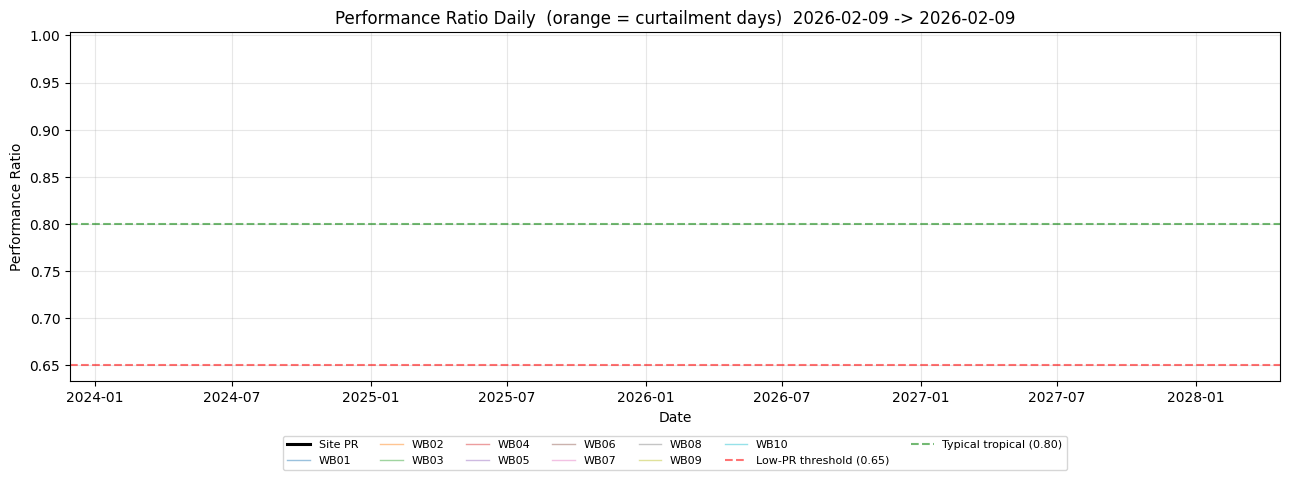


[PR] saved daily PR (with Wave 11 curtailment cols) -> /content/drive/MyDrive/Cek PV String/outputs/pr_daily_20260209.csv


In [6]:
# Cell 5 - Performance Ratio + Curtailment Cross-Check (Wave 7 + Wave 11)
# --------------------------------------------------------------------------
# Wave 7: GenerationLoader (Summary PV daily kWh) + compute_pr per IEC 61724-1
# Wave 11: cross-check low-PR days vs Curtailment (col R) + Deem Dispatch (col Q)
#
# Semua modul di-import langsung dari main repo package pv_pipeline.

import os
import pandas as pd
import matplotlib.pyplot as plt

from pv_pipeline.generation.loader import GenerationLoader
from pv_pipeline.physics import compute_pr

print("[PR] modules loaded from pv_pipeline (physics.compute_pr + GenerationLoader)")

# --- Pre-check: combined_df + cfg + DATA_DATESTR + POA provider from Cell 4 ----
if "combined_df" not in globals():
    raise RuntimeError("[PR] combined_df missing. Run Cell 1 + Cell 2 dulu.")
if "cfg" not in globals():
    raise RuntimeError("[PR] cfg missing. Run Cell 4 dulu (M2 Pipeline).")
if "poa_provider" not in globals():
    raise RuntimeError("[PR] poa_provider missing. Run Cell 4 dulu.")

DATA_DATESTR = globals().get("DATA_DATESTR", "unknown")

# --- 1. Load generation data ------------------------------------------------
GEN_XLSX = "raw data input/IKN Generation.xlsx"
if not os.path.exists(GEN_XLSX):
    print(f"[PR] skipped: {GEN_XLSX} not found.")
    raise SystemExit

gen_loader = GenerationLoader(GEN_XLSX)
print(f"[PR] generation loader : {gen_loader.xlsx_path}")
print(f"     date range        : {gen_loader.df.index.min().date()} -> {gen_loader.df.index.max().date()}")
print(f"     columns available : {list(gen_loader.df.columns)}")

# --- 2. Determine date range ------------------------------------------------
st = pd.to_datetime(combined_df["Start Time"], errors="coerce").dropna()
date_index = pd.date_range(st.min().normalize(), st.max().normalize(), freq="D")
print(f"\n[PR] analysis range    : {date_index.min().date()} -> {date_index.max().date()} ({len(date_index)} day(s))")

# --- 3. Daily POA integration per WB -> site average (Wave 11 hotfix #2) ----
# POAProvider.get_poa(timestamps, wb_id) returns 5-min series per WB. Build a
# 5-min grid for the analysis period, loop per WB, average untuk site POA.
SAMPLE_HOURS = 5 / 60.0
_start_ts = pd.Timestamp(date_index.min())
_end_ts = pd.Timestamp(date_index.max()) + pd.Timedelta(days=1) - pd.Timedelta(minutes=5)
ts_5min = pd.date_range(_start_ts, _end_ts, freq="5min")

_wb_all = [f"WB{n:02d}" for n in range(1, 11)]
poa_per_wb_5min = {}
for _wb in _wb_all:
    try:
        poa_per_wb_5min[_wb] = poa_provider.get_poa(ts_5min, _wb)
    except (KeyError, ValueError) as _exc:
        print(f"[PR] WARNING get_poa({_wb}) failed: {_exc.__class__.__name__}: {_exc}")
        poa_per_wb_5min[_wb] = pd.Series(float("nan"), index=ts_5min)

poa_per_wb_df = pd.DataFrame(poa_per_wb_5min)
poa_site_5min = poa_per_wb_df.mean(axis=1)  # site-average POA W/m^2

# Daily kWh/m^2 integration.
poa_site_daily_kwh = (poa_site_5min * SAMPLE_HOURS / 1000.0).resample("D").sum()
if poa_site_daily_kwh.index.tz is not None:
    poa_site_daily_kwh.index = poa_site_daily_kwh.index.tz_localize(None)
poa_aligned = poa_site_daily_kwh.reindex(date_index)
print(f"[PR] POA site daily (kWh/m^2) describe :")
print(poa_aligned.describe().round(2).to_string())

# --- 4. Site-level PR -------------------------------------------------------
capacity_site_kwp = float(cfg.get("generation", {}).get("capacity_kwp", 71500.0))
energy_site = gen_loader.get_daily(date_index, "total_kwh")
pr_site = compute_pr(energy_site, poa_aligned, capacity_site_kwp)
pr_site.name = "pr_site"

print(f"\n[PR] site capacity     : {capacity_site_kwp:.0f} kWp")
print(f"     PR site describe : ")
print(pr_site.describe().round(3).to_string())

# --- 5. Wave 11: curtailment cross-check for low-PR days --------------------
LOW_PR_THRESHOLD = 0.65
low_pr = pr_site[pr_site < LOW_PR_THRESHOLD].dropna()
print(f"\n[PR] Low-PR days (<{LOW_PR_THRESHOLD}): {len(low_pr)}")

curtail_all = gen_loader.get_daily(date_index, "curtailment_flag")
deem_all = gen_loader.get_daily(date_index, "deem_dispatch_kwh")

if not low_pr.empty:
    crosscheck = pd.DataFrame({
        "pr": low_pr.round(3),
        "curtailment": curtail_all.reindex(low_pr.index).values,
        "deem_dispatch_kwh": deem_all.reindex(low_pr.index).round(0).values,
    })
    print("\n[PR/Wave 11] Curtailment cross-check on low-PR days:")
    print(crosscheck.to_string())

    flag_for_low = curtail_all.reindex(low_pr.index)
    explained = int((flag_for_low == "Yes").sum())
    unexplained = int((flag_for_low == "No").sum())
    unknown = int(flag_for_low.isna().sum())
    print(f"\n[PR/Wave 11] Verdict:")
    print(f"  Low-PR explained by curtailment       : {explained:>3d}  (operational, not fault)")
    print(f"  Low-PR UNEXPLAINED (potential fault)  : {unexplained:>3d}  *** investigate ***")
    print(f"  Low-PR with missing curtailment data  : {unknown:>3d}")

# --- 6. Per-WB PR (each WB uses its OWN daily POA) --------------------------
_cap_per_wb_cfg = cfg.get("generation", {}).get("capacity_kwp_per_wb", {}) or {}
capacity_wb_kwp = {wb: float(_cap_per_wb_cfg.get(wb, capacity_site_kwp / 10.0))
                   for wb in _wb_all}
wb_keys = _wb_all

# Per-WB daily POA integration kWh/m^2 (re-use poa_per_wb_df from section 3).
poa_wb_daily = {}
for wb in wb_keys:
    _daily = (poa_per_wb_df[wb] * SAMPLE_HOURS / 1000.0).resample("D").sum()
    if _daily.index.tz is not None:
        _daily.index = _daily.index.tz_localize(None)
    poa_wb_daily[wb] = _daily.reindex(date_index)

pr_wb = {wb: compute_pr(gen_loader.get_daily(date_index, wb),
                        poa_wb_daily[wb], capacity_wb_kwp[wb])
         for wb in wb_keys}
pr_wb_df = pd.DataFrame(pr_wb)
print("\n[PR] per-WB capacity (kWp): "
      + ", ".join(f"{wb}={capacity_wb_kwp[wb]:.0f}" for wb in wb_keys))
print(f"     PR per-WB mean   :")
print(pr_wb_df.mean().round(3).to_string())

# --- 7. Plot (orange vertical bands = curtailment days) ---------------------
fig, ax = plt.subplots(figsize=(13, 5))
yes_dates = curtail_all.index[curtail_all == "Yes"]
for d in yes_dates:
    ax.axvline(d, color="orange", alpha=0.18, linewidth=2, zorder=0)

ax.plot(pr_site.index, pr_site.values, label="Site PR", color="black", linewidth=2.2, zorder=5)
for wb in wb_keys:
    ax.plot(pr_wb_df.index, pr_wb_df[wb].values, alpha=0.45, linewidth=1.0, label=wb)

ax.axhline(LOW_PR_THRESHOLD, ls="--", color="red", alpha=0.55,
           label=f"Low-PR threshold ({LOW_PR_THRESHOLD})")
ax.axhline(0.80, ls="--", color="green", alpha=0.55, label="Typical tropical (0.80)")
ax.set_xlabel("Date")
ax.set_ylabel("Performance Ratio")
ax.set_title(f"Performance Ratio Daily  (orange = curtailment days)  "
             f"{date_index.min().date()} -> {date_index.max().date()}")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.27), ncol=7, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 8. Save PR CSV (Wave 11: include curtailment + deem_dispatch cols) -----
REPO_DIR = globals().get("REPO_DIR", os.getcwd())
out_dir = os.path.join(REPO_DIR, cfg["m2e"].get("output_dir", "outputs"))
os.makedirs(out_dir, exist_ok=True)
pr_csv = os.path.join(out_dir, f"pr_daily_{DATA_DATESTR}.csv")
pr_combined = pd.concat({
    "pr_site": pr_site,
    **{f"pr_{wb}": pr_wb_df[wb] for wb in wb_keys},
    "curtailment_flag": curtail_all,
    "deem_dispatch_kwh": deem_all,
}, axis=1)
pr_combined.to_csv(pr_csv, encoding="utf-8")
print(f"\n[PR] saved daily PR (with Wave 11 curtailment cols) -> {pr_csv}")


[sanity] import mode = clean
[sanity] data dates    = 20260209  (1 day(s))
[sanity] dates source  = combined_df['Start Time']
[sanity] chart anchor  = 2026-02-09
[sanity] geometry yaml = config/site_geometry.yaml
[sanity] panel    yaml = config/panel_spec.yaml
[sanity] POA  ALL_SOURCES   = ['pyranometer_per_ws', 'pyranometer_avg', 'pvlib_clearsky_ineichen', 'pvlib_clearsky_simplified_solis', 'pvlib_clearsky_haurwitz', 'auto']
[sanity] Tcell ALL_SOURCES = ['measured_per_ws', 'measured_overall_avg', 'sapm', 'auto']

[sanity] query timestamps: 13 entries (2026-02-09 06:00:00 -> 2026-02-09 18:00:00)

[PanelSpec] Jinko Solar JKM625N 78HL4-BDV
  WB  modules/string  Voc_string_STC (V)  Voc_string_cold@10C (V)  margin_to_1500V (%)
WB01              24              1337.3                   1387.4                  7.5
WB02              24              1337.3                   1387.4                  7.5
WB03              26              1448.7                   1503.0                 -0.2
WB04  

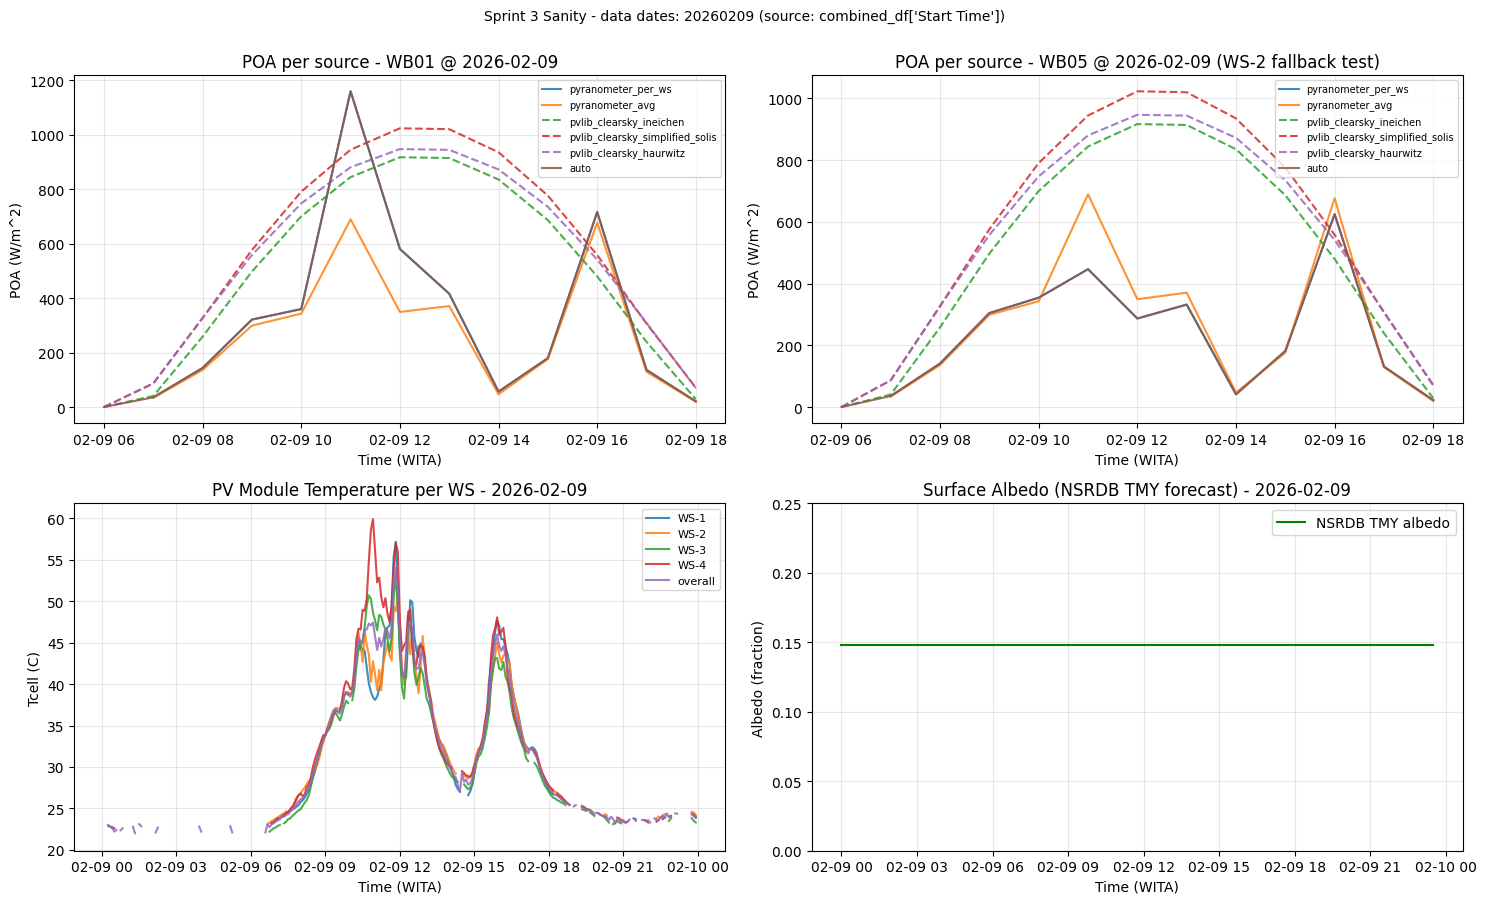


[sanity] Sprint 3.1 + 3.2 OK. Dates used: 20260209


In [7]:
# Cell 6 - Sprint 3.1 + 3.2 Sanity: POA + PanelSpec + Albedo + Tcell
# --------------------------------------------------------------------
# Auto-detect tanggal dari combined_df['Start Time'] (sama pattern dgn Cell 4).
# Kalau combined_df tidak ada (user run Cell 5 standalone), fallback ke
# 2026-05-07 yang ada di POA xlsx range.
#
# Verifikasi:
#   - POAProvider load 5 sumber pyranometer + 3 model pvlib clear-sky
#     (dengan dynamic albedo dari NSRDB TMY).
#   - AlbedoLoader: NSRDB TMY forecast, 30-min resolution.
#   - CellTempProvider: 2025-2026 @ 5-min, per-WS + Overall, WB01/02 piggyback
#     ke WS-4 (no WS-5 Tcell).
#   - PanelSpec parse Jinko JKM625N + per-WB modules_per_string (24 vs 26).
#   - Auto fallback chain bekerja saat data missing.

import os
import sys
import importlib.util as _iu
import types
import pandas as pd

# --- Defensive import block --------------------------------------------------
WORKTREE_PV_PIPELINE = r".claude/worktrees/modest-shockley-9c31f4/pv_pipeline"
WORKTREE_CONFIG_DIR  = r".claude/worktrees/modest-shockley-9c31f4/config"


def _try_clean_imports():
    try:
        from pv_pipeline.poa import POAProvider, ALL_SOURCES, SOURCE_AUTO, AlbedoLoader
        from pv_pipeline.panel_spec import PanelSpec
        from pv_pipeline.cell_temp import (
            CellTempProvider,
            ALL_SOURCES as TC_ALL_SOURCES,
            SOURCE_AUTO as TC_SOURCE_AUTO,
        )
        return (
            POAProvider, ALL_SOURCES, SOURCE_AUTO, AlbedoLoader,
            PanelSpec, CellTempProvider, TC_ALL_SOURCES, TC_SOURCE_AUTO,
            "clean",
        )
    except Exception as exc:
        print(f"[sanity] clean import gagal ({exc.__class__.__name__}): {exc}")
        return None


def _load_from_worktree():
    alias = "pv_pipeline_sprint3"
    pkg = types.ModuleType(alias)
    pkg.__path__ = [WORKTREE_PV_PIPELINE]
    sys.modules[alias] = pkg
    poa_pkg = types.ModuleType(f"{alias}.poa")
    poa_pkg.__path__ = [os.path.join(WORKTREE_PV_PIPELINE, "poa")]
    sys.modules[f"{alias}.poa"] = poa_pkg

    def _load(filepath, fq_name):
        spec = _iu.spec_from_file_location(fq_name, filepath)
        mod = _iu.module_from_spec(spec)
        sys.modules[fq_name] = mod
        spec.loader.exec_module(mod)
        return mod

    panel_spec_mod = _load(
        os.path.join(WORKTREE_PV_PIPELINE, "panel_spec.py"),
        f"{alias}.panel_spec",
    )
    cell_temp_mod = _load(
        os.path.join(WORKTREE_PV_PIPELINE, "cell_temp.py"),
        f"{alias}.cell_temp",
    )
    for sub in ["loader", "pvlib_estimator", "albedo_loader", "provider"]:
        _load(
            os.path.join(WORKTREE_PV_PIPELINE, "poa", f"{sub}.py"),
            f"{alias}.poa.{sub}",
        )

    provider_mod = sys.modules[f"{alias}.poa.provider"]
    albedo_mod   = sys.modules[f"{alias}.poa.albedo_loader"]
    return (
        provider_mod.POAProvider,
        provider_mod.ALL_SOURCES,
        provider_mod.SOURCE_AUTO,
        albedo_mod.AlbedoLoader,
        panel_spec_mod.PanelSpec,
        cell_temp_mod.CellTempProvider,
        cell_temp_mod.ALL_SOURCES,
        cell_temp_mod.SOURCE_AUTO,
        "worktree",
    )


_result = _try_clean_imports()
if _result is None:
    _result = _load_from_worktree()
(POAProvider, ALL_SOURCES, SOURCE_AUTO, AlbedoLoader,
 PanelSpec, CellTempProvider, TC_ALL_SOURCES, TC_SOURCE_AUTO,
 _import_mode) = _result
print(f"[sanity] import mode = {_import_mode}")


# --- Resolve config paths ----------------------------------------------------
def _resolve(cfg_filename: str) -> str:
    for base in ["config", WORKTREE_CONFIG_DIR]:
        p = os.path.join(base, cfg_filename)
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"[sanity] {cfg_filename!r} tidak ditemukan.")


GEOM_PATH  = _resolve("site_geometry.yaml")
PANEL_PATH = _resolve("panel_spec.yaml")


# --- Auto-detect tanggal dari combined_df['Start Time'] ----------------------
# Pattern sama dengan Cell 4 (M2 Pipeline) -> tanggal output otomatis ikut data.
def _auto_detect_dates():
    """Returns (dates_list, date_str, source_label).

    Priority:
        1. globals['combined_df']['Start Time'] (typical: setelah Cell 1-4 jalan).
        2. Fallback ke 2026-05-07 (single day, ada di POA xlsx range).
    """
    if "combined_df" in globals():
        try:
            df = globals()["combined_df"]
            if "Start Time" in df.columns:
                st = pd.to_datetime(df["Start Time"], errors="coerce").dropna()
                if not st.empty:
                    dates = sorted(st.dt.date.unique())
                    if len(dates) == 1:
                        ds = dates[0].strftime("%Y%m%d")
                    else:
                        ds = f"{dates[0].strftime('%Y%m%d')}-{dates[-1].strftime('%Y%m%d')}"
                    return dates, ds, "combined_df['Start Time']"
        except Exception as exc:
            print(f"[sanity] gagal baca combined_df Start Time: {exc}")
    # Fallback (Cell 5 standalone, tidak ada combined_df).
    fb = pd.Timestamp("2026-05-07").date()
    return [fb], fb.strftime("%Y%m%d"), "fallback (combined_df tidak di-scope)"


DATA_DATES, DATA_DATESTR, DATA_DATESRC = _auto_detect_dates()
CHART_DATE = DATA_DATES[0]   # tanggal pertama untuk detail chart
CHART_DATE_TS = pd.Timestamp(CHART_DATE)

print(f"[sanity] data dates    = {DATA_DATESTR}  ({len(DATA_DATES)} day(s))")
print(f"[sanity] dates source  = {DATA_DATESRC}")
print(f"[sanity] chart anchor  = {CHART_DATE_TS.strftime('%Y-%m-%d')}")
print(f"[sanity] geometry yaml = {GEOM_PATH}")
print(f"[sanity] panel    yaml = {PANEL_PATH}")
print(f"[sanity] POA  ALL_SOURCES   = {ALL_SOURCES}")
print(f"[sanity] Tcell ALL_SOURCES = {TC_ALL_SOURCES}\n")


# Build daylight hourly timestamps untuk semua data dates (multi-day safe).
def _daylight_hourly(dates, hour_start=6, hour_end=18, freq="1h"):
    parts = []
    for d in dates:
        d_ts = pd.Timestamp(d)
        parts.append(pd.date_range(
            d_ts + pd.Timedelta(hours=hour_start),
            d_ts + pd.Timedelta(hours=hour_end),
            freq=freq,
        ))
    return pd.DatetimeIndex(sorted(set(t for p in parts for t in p)))


SANITY_TS = _daylight_hourly(DATA_DATES, hour_start=6, hour_end=18, freq="1h")
print(f"[sanity] query timestamps: {len(SANITY_TS)} entries "
      f"({SANITY_TS.min()} -> {SANITY_TS.max()})\n")


# --- Demo 1: PanelSpec -------------------------------------------------------
spec = PanelSpec.from_yaml(PANEL_PATH)
print(f"[PanelSpec] {spec.panel_model}")
panel_rows = []
for wb in [f"WB{i:02d}" for i in range(1, 11)]:
    n = spec.modules_per_string(wb)
    voc_stc  = spec.voc_string_stc(wb)
    voc_cold = spec.voc_string_at_design_min_temp(wb, min_cell_temp_c=10.0)
    margin   = (1.0 - voc_cold / spec.max_system_voltage_v) * 100.0
    panel_rows.append({
        "WB": wb, "modules/string": n,
        "Voc_string_STC (V)": round(voc_stc, 1),
        "Voc_string_cold@10C (V)": round(voc_cold, 1),
        "margin_to_1500V (%)": round(margin, 2),
    })
print(pd.DataFrame(panel_rows).to_string(index=False))


# --- Demo 2: AlbedoLoader (auto-detect date range) ---------------------------
print("\n[AlbedoLoader] (NSRDB TMY 5-year average forecast)")
albedo_loader = AlbedoLoader.from_geometry_yaml(GEOM_PATH)
if albedo_loader is None:
    print("  (albedo xlsx tidak di-config, skip)")
else:
    print(f"  source: {albedo_loader.xlsx_path}  rows={len(albedo_loader.series)}")
    print(f"  date_range: {albedo_loader.series.index.min()} -> {albedo_loader.series.index.max()}")
    # Cek apakah data date dalam range albedo xlsx.
    alb_in_range = (
        CHART_DATE_TS >= albedo_loader.series.index.min()
        and CHART_DATE_TS <= albedo_loader.series.index.max()
    )
    if not alb_in_range:
        print(f"  WARNING: chart date {CHART_DATE} di luar range albedo xlsx -> nilai akan NaN/fallback")
    day_ts = pd.date_range(CHART_DATE_TS, CHART_DATE_TS + pd.Timedelta(hours=23, minutes=30), freq="30min")
    day_alb = albedo_loader.get_albedo(day_ts)
    valid_alb = day_alb.dropna()
    if not valid_alb.empty:
        print(f"  {CHART_DATE} 24h albedo: min={valid_alb.min():.3f}  "
              f"max={valid_alb.max():.3f}  mean={valid_alb.mean():.3f}  "
              f"({valid_alb.size}/{day_alb.size} non-NaN)")
    else:
        print(f"  {CHART_DATE} albedo: all NaN (out of NSRDB range)")


# --- Demo 3: POAProvider (multi-source + dynamic albedo) --------------------
prov = POAProvider.from_yaml(GEOM_PATH)
print(f"\n[POAProvider] pyranometer={bool(prov.pyranometer)}  pvlib={bool(prov.pvlib)}  "
      f"albedo_loader={bool(prov.albedo_loader)}")
print(f"  auto_fallback_chain = {prov.auto_fallback_chain}")

# Check apakah data date dalam range pyranometer xlsx.
if prov.pyranometer is not None:
    pyr_in_range = (
        CHART_DATE_TS >= prov.pyranometer.df.index.min()
        and CHART_DATE_TS <= prov.pyranometer.df.index.max()
    )
    if not pyr_in_range:
        print(f"  WARNING: chart date {CHART_DATE} di luar range pyranometer xlsx "
              f"({prov.pyranometer.df.index.min()} -> {prov.pyranometer.df.index.max()}) "
              "-> pyranometer_per_ws & pyranometer_avg akan NaN, auto fallback ke pvlib")

# Hourly multi-source per WB (pakai SANITY_TS yang auto-detect).
df_poa_wb01 = prov.get_poa_all_sources(SANITY_TS, "WB01")
df_poa_wb05 = prov.get_poa_all_sources(SANITY_TS, "WB05")
# Limit output ke chart_date saja kalau multi-day (biar tabel manageable).
mask01 = df_poa_wb01.index.normalize() == CHART_DATE_TS
mask05 = df_poa_wb05.index.normalize() == CHART_DATE_TS
print(f"\n[POAProvider] WB=WB01 POA (W/m^2) @ {CHART_DATE} daylight hourly:")
print(df_poa_wb01[mask01].round(1).to_string())
print(f"\n[POAProvider] WB=WB05 POA (W/m^2) @ {CHART_DATE} (test fallback chain):")
print(df_poa_wb05[mask05].round(1).to_string())


# --- Demo 4: CellTempProvider (auto-detect date range) ----------------------
print("\n[CellTempProvider]")
ct_prov = CellTempProvider.from_geometry_yaml(GEOM_PATH)
print(f"  source: {ct_prov.xlsx_path}  rows={len(ct_prov.df)}")
print(f"  date_range: {ct_prov.df.index.min()} -> {ct_prov.df.index.max()}")
print(f"  WB->WS mapping (Tcell):")
for wb in [f"WB{i:02d}" for i in range(1, 11)]:
    print(f"    {wb} -> {ct_prov.wb_to_ws.get(wb, '(no mapping)')}")

# Check apakah data date dalam range Tcell xlsx.
tcell_in_range = (
    CHART_DATE_TS >= ct_prov.df.index.min()
    and CHART_DATE_TS <= ct_prov.df.index.max()
)
if not tcell_in_range:
    print(f"  WARNING: chart date {CHART_DATE} di luar range Tcell xlsx -> nilai akan NaN")

tcell_ts = _daylight_hourly(DATA_DATES, hour_start=6, hour_end=18, freq="3h")
mask_chart = tcell_ts.normalize() == CHART_DATE_TS
for wb in ["WB01", "WB05", "WB10"]:
    df_tc = ct_prov.get_tcell_all_sources(tcell_ts, wb)
    print(f"\n  WB={wb} Tcell (C) per source @ {CHART_DATE}:")
    print(df_tc[mask_chart].round(2).to_string())


# --- Demo 5: Visualisasi (POA + Tcell + Albedo) -----------------------------
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))

    chart_date_str = CHART_DATE.strftime("%Y-%m-%d")

    # Filter ke chart_date only untuk kebersihan visual (kalau multi-day data).
    poa_wb01_chart = df_poa_wb01[df_poa_wb01.index.normalize() == CHART_DATE_TS]
    poa_wb05_chart = df_poa_wb05[df_poa_wb05.index.normalize() == CHART_DATE_TS]

    # (top-left) POA WB01
    ax = axes[0, 0]
    for col in poa_wb01_chart.columns:
        style = "--" if col.startswith("pvlib") else "-"
        ax.plot(poa_wb01_chart.index, poa_wb01_chart[col], style, label=col, alpha=0.85)
    ax.set_title(f"POA per source - WB01 @ {chart_date_str}")
    ax.set_xlabel("Time (WITA)")
    ax.set_ylabel("POA (W/m^2)")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)

    # (top-right) POA WB05
    ax = axes[0, 1]
    for col in poa_wb05_chart.columns:
        style = "--" if col.startswith("pvlib") else "-"
        ax.plot(poa_wb05_chart.index, poa_wb05_chart[col], style, label=col, alpha=0.85)
    ax.set_title(f"POA per source - WB05 @ {chart_date_str} (WS-2 fallback test)")
    ax.set_xlabel("Time (WITA)")
    ax.set_ylabel("POA (W/m^2)")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)

    # (bottom-left) Tcell per WS, full day curve
    ax = axes[1, 0]
    if len(ct_prov.df) > 0:
        day_start = CHART_DATE_TS
        day_end = CHART_DATE_TS + pd.Timedelta(hours=23, minutes=59, seconds=59)
        day_slice = ct_prov.df.loc[day_start:day_end]
        if not day_slice.empty:
            for col in day_slice.columns:
                ax.plot(day_slice.index, day_slice[col], label=col, alpha=0.85)
            ax.set_title(f"PV Module Temperature per WS - {chart_date_str}")
        else:
            ax.text(0.5, 0.5, f"Tcell data tidak tersedia untuk {chart_date_str}",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"PV Module Temperature - {chart_date_str} (NO DATA)")
        ax.set_xlabel("Time (WITA)")
        ax.set_ylabel("Tcell (C)")
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(True, alpha=0.3)

    # (bottom-right) Albedo NSRDB 24-hour curve
    ax = axes[1, 1]
    if albedo_loader is not None:
        day_ts2 = pd.date_range(CHART_DATE_TS,
                                CHART_DATE_TS + pd.Timedelta(hours=23, minutes=30),
                                freq="30min")
        day_alb = albedo_loader.get_albedo(day_ts2)
        if day_alb.notna().any():
            ax.plot(day_ts2, day_alb, "g-", label="NSRDB TMY albedo")
            ax.set_title(f"Surface Albedo (NSRDB TMY forecast) - {chart_date_str}")
            ax.set_ylim(0, max(0.25, day_alb.max() * 1.1))
        else:
            ax.text(0.5, 0.5, f"Albedo data tidak tersedia untuk {chart_date_str}",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"Albedo - {chart_date_str} (NO DATA)")
        ax.set_xlabel("Time (WITA)")
        ax.set_ylabel("Albedo (fraction)")
        ax.legend(loc="upper right")
        ax.grid(True, alpha=0.3)

    plt.suptitle(f"Sprint 3 Sanity - data dates: {DATA_DATESTR} "
                 f"(source: {DATA_DATESRC})", fontsize=10, y=1.00)
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"[sanity] matplotlib plot skipped: {exc}")

print(f"\n[sanity] Sprint 3.1 + 3.2 OK. Dates used: {DATA_DATESTR}")


In [8]:
# Cell 7 - Sprint 3.3: Baseline Accumulator (manual daily save)
# ---------------------------------------------------------------
# Save data NORMAL ke baseline/{YYYY-MM}/{YYYY-MM-DD}.{parquet,csv} untuk
# nantinya dipakai LSTM-AE training (Sprint 4).
#
# Hybrid NORMAL labeling:
#   1. User-marked maintenance windows (dari config/baseline.yaml).
#   2. Auto-skip inverter-day yang punya finding CRITICAL/HIGH di Cell 4.
#
# Prereq:
#   - Cell 1 + Cell 2 sudah jalan (combined_df di scope).
#   - Cell 4 sudah jalan (findings list di scope) [optional - kalau tidak ada,
#     hanya maintenance windows yang di-skip; auto-skip findings tidak aktif].
#
# Output:
#   baseline/{YYYY-MM}/{YYYY-MM-DD}.parquet  (primary)
#   baseline/{YYYY-MM}/{YYYY-MM-DD}.csv      (backup)
#   baseline/manifest.csv                     (audit trail)
#
# Setelah save: user upload manual ke Drive folder yang sama dengan Huawei xlsx.

import os
import warnings
import pandas as pd

from pv_pipeline.baseline import BaselineAccumulator, MaintenancePeriod

warnings.simplefilter("ignore", UserWarning)

REPO_DIR = globals().get("REPO_DIR", os.getcwd())
print("[baseline] BaselineAccumulator loaded from pv_pipeline")


# --- Resolve config path -----------------------------------------------------
def _resolve_baseline_config():
    for base in [os.path.join(REPO_DIR, "config"), "config"]:
        p = os.path.join(base, "baseline.yaml")
        if os.path.exists(p):
            return p
    return None


BASELINE_CFG_PATH = _resolve_baseline_config()
if BASELINE_CFG_PATH is None:
    print("[baseline] config/baseline.yaml tidak ditemukan -> pakai defaults (no maintenance windows)")
    acc = BaselineAccumulator()
else:
    print(f"[baseline] config: {BASELINE_CFG_PATH}")
    acc = BaselineAccumulator.from_yaml(BASELINE_CFG_PATH)

print(f"[baseline] base_dir={acc.base_dir!r}  formats={acc.output_formats}")
print(f"[baseline] auto_skip_severity={acc.auto_skip_severity}  "
      f"min_rows_per_inverter={acc.min_rows_per_inverter}  overwrite={acc.overwrite}")
print(f"[baseline] maintenance_periods loaded: {len(acc.maintenance_periods)}")
for i, p in enumerate(acc.maintenance_periods):
    desc = f"all inverters" if p.affect_all else (
        f"specific [{','.join(p.affected)}]" if p.affected
        else f"WB prefix [{','.join(p.affect_wb_prefix)}]"
    )
    print(f"  [{i}] {p.start} -> {p.end}  {desc}  reason={p.reason!r}")


# --- Pre-check combined_df ---------------------------------------------------
if "combined_df" not in globals():
    raise RuntimeError(
        "[baseline] combined_df tidak ditemukan. Jalankan Cell 1 + Cell 2 terlebih dahulu."
    )

required_cols = ["Inverter_ID", "Start Time"]
missing = [c for c in required_cols if c not in combined_df.columns]
if missing:
    raise RuntimeError(f"[baseline] combined_df missing required columns: {missing}")


# --- Auto-detect tanggal dari combined_df['Start Time'] ----------------------
def _auto_detect_dates(df):
    st = pd.to_datetime(df["Start Time"], errors="coerce").dropna()
    if st.empty:
        raise RuntimeError("[baseline] combined_df['Start Time'] kosong/invalid")
    dates = sorted(st.dt.date.unique())
    if len(dates) == 1:
        ds = dates[0].strftime("%Y%m%d")
    else:
        ds = f"{dates[0].strftime('%Y%m%d')}-{dates[-1].strftime('%Y%m%d')}"
    return dates, ds


DATA_DATES, DATA_DATESTR = _auto_detect_dates(combined_df)
print(f"\n[baseline] data dates = {DATA_DATESTR}  ({len(DATA_DATES)} day(s))")
print(f"[baseline] combined_df shape = {combined_df.shape}")


# --- Pickup findings dari Cell 4 (kalau ada) ---------------------------------
findings_to_skip = globals().get("findings", None)
if findings_to_skip is None:
    print("\n[baseline] 'findings' tidak ada di scope (Cell 6 belum dijalankan).")
    print("  -> Auto-skip findings di-skip; hanya maintenance windows yang di-filter.")
else:
    sev_counts = {}
    for f in findings_to_skip:
        sev = f.severity.value if hasattr(f.severity, "value") else str(f.severity)
        sev_counts[sev] = sev_counts.get(sev, 0) + 1
    print(f"\n[baseline] 'findings' di scope: {len(findings_to_skip)} records "
          f"({sev_counts})")
    print(f"  -> Auto-skip inverters dengan severity in {acc.auto_skip_severity}")


# --- Run accumulator: single-day vs multi-day --------------------------------
results = []
if len(DATA_DATES) == 1:
    day_str = DATA_DATES[0].strftime("%Y%m%d")
    print(f"\n[baseline] running accumulator untuk {day_str}...")
    result = acc.run(combined_df, day_str, findings=findings_to_skip)
    results.append(result)
else:
    df_ts = pd.to_datetime(combined_df["Start Time"], errors="coerce")
    for d in DATA_DATES:
        day_str = d.strftime("%Y%m%d")
        day_mask = df_ts.dt.date == d
        df_day = combined_df.loc[day_mask].copy()
        if df_day.empty:
            print(f"\n[baseline] {day_str}: 0 rows, skip")
            continue
        print(f"\n[baseline] running accumulator untuk {day_str} ({len(df_day)} rows)...")
        result = acc.run(df_day, day_str, findings=findings_to_skip)
        results.append(result)


# --- Summary report ----------------------------------------------------------
print("\n[baseline] ========== SUMMARY ==========")
for result in results:
    s = result["summary"]
    print(f"\n  Date: {result['date_str']}")
    print(f"    rows_total      : {s.rows_total}")
    print(f"    rows_kept       : {s.rows_kept}  ({100*s.rows_kept/max(s.rows_total,1):.1f}%)")
    print(f"    skipped_maint   : {s.rows_skipped_maintenance} (matches={s.maintenance_matches})")
    print(f"    skipped_findings: {s.rows_skipped_findings} "
          f"({len(s.inverters_skipped_findings)} inverters)")
    print(f"    skipped_minrows : {s.rows_skipped_min_rows} "
          f"({len(s.inverters_skipped_min_rows)} sparse inverters)")
    print(f"    pv_nanned       : {s.rows_pv_nanned} rows touched "
          f"({len(s.pv_strings_skipped_findings)} PV strings NaN'd)")
    print(f"    inverters_kept  : {s.inverters_kept} / {s.inverters_total}")
    print(f"    parquet         : {result['paths']['parquet'] or '(skipped)'}")
    print(f"    csv             : {result['paths']['csv'] or '(skipped)'}")
    if s.inverters_skipped_findings:
        print(f"    auto-skip list  : {', '.join(s.inverters_skipped_findings)}")
    if s.pv_strings_skipped_findings:
        print(f"    pv-skip list    : {', '.join(s.pv_strings_skipped_findings)}")


# --- Manifest report ---------------------------------------------------------
manifest_path = acc.manifest_path()
if os.path.exists(manifest_path):
    print(f"\n[baseline] manifest: {manifest_path}")
    manifest_df = pd.read_csv(manifest_path)
    print(f"  total accumulated dates: {len(manifest_df)}")
    if len(manifest_df) > 0:
        recent = manifest_df.tail(10)
        print("  last 10 rows:")
        print(recent[["date", "rows_total", "rows_kept",
                      "rows_skipped_maintenance", "rows_skipped_findings",
                      "inverters_kept"]].to_string(index=False))


print(f"\n[baseline] DONE. Upload {acc.base_dir}/ ke Drive folder yang sama dengan Huawei xlsx.")


[baseline] BaselineAccumulator loaded from pv_pipeline
[baseline] config: /content/drive/MyDrive/Cek PV String/config/baseline.yaml
[baseline] base_dir='baseline'  formats=('parquet', 'csv')
[baseline] auto_skip_severity=('CRITICAL', 'HIGH')  min_rows_per_inverter=30  overwrite=False
[baseline] maintenance_periods loaded: 0

[baseline] data dates = 20260209  (1 day(s))
[baseline] combined_df shape = (21439, 155)

[baseline] 'findings' di scope: 0 records ({})
  -> Auto-skip inverters dengan severity in ('CRITICAL', 'HIGH')

[baseline] running accumulator untuk 20260209...

[baseline] ========== SUMMARY ==========

  Date: 20260209
    rows_total      : 21439
    rows_kept       : 21439  (100.0%)
    skipped_maint   : 0 (matches=0)
    skipped_findings: 0 (0 inverters)
    skipped_minrows : 0 (0 sparse inverters)
    pv_nanned       : 0 rows touched (0 PV strings NaN'd)
    inverters_kept  : 144 / 144
    parquet         : (skipped)
    csv             : baseline/2026-02/2026-02-09.csv


In [9]:
# Cell 8 — Simpan df_plot ke CSV dgn nama mengikuti tanggal data
# (dependency google.colab.files DIPERTAHANKAN sesuai instruksi Phase 0).
import os
import pandas as pd
from google.colab import files

if 'df_plot' not in globals():
    raise RuntimeError("df_plot tidak ditemukan. Jalankan Cell 3 terlebih dahulu.")
if df_plot.empty:
    raise ValueError("df_plot kosong, tidak ada data untuk disimpan.")

start_times = pd.to_datetime(df_plot['Start Time'], errors='coerce').dropna()
if start_times.empty:
    raise ValueError("Kolom 'Start Time' di df_plot tidak punya tanggal valid.")

unique_dates = sorted(start_times.dt.date.unique())
if len(unique_dates) == 1:
    date_str = unique_dates[0].strftime("%Y%m%d")
else:
    date_str = f"{unique_dates[0].strftime('%Y%m%d')}-{unique_dates[-1].strftime('%Y%m%d')}"
    print(f"  ⚠ Data mencakup {len(unique_dates)} tanggal "
          f"({unique_dates[0]} s.d. {unique_dates[-1]})")

OUTPUT_FILENAME = f"{date_str}.csv"
df_plot.to_csv(OUTPUT_FILENAME, index=False, encoding='utf-8')

file_size_kb = os.path.getsize(OUTPUT_FILENAME) / 1024
print(f"✓ File berhasil dibuat di Colab")
print(f"  Nama        : {OUTPUT_FILENAME}")
print(f"  Ukuran      : {file_size_kb:.1f} KB")
print(f"  Baris       : {len(df_plot):,}")
print(f"  Kolom       : {df_plot.shape[1]}")
print(f"  Tanggal data: {date_str}")

print("\nMemulai download...")
files.download(OUTPUT_FILENAME)
print(f"\n✓ '{OUTPUT_FILENAME}' akan masuk ke folder Downloads browser Anda.")

✓ File berhasil dibuat di Colab
  Nama        : 20260209.csv
  Ukuran      : 21633.3 KB
  Baris       : 21,439
  Kolom       : 156
  Tanggal data: 20260209

Memulai download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✓ '20260209.csv' akan masuk ke folder Downloads browser Anda.
